# CNN trained from scratch

In [19]:
import shutil
from pathlib import Path

import os

import soundfile as sf

import librosa
import librosa.display
import IPython.display as ip
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
!pip install audformat

import audformat

!wget https://zenodo.org/record/7447302/files/emodb.zip #Getting the database

!unzip emodb.zip

db = audformat.Database.load('emodb')

#Separation of the dataset into training and testing

df_test = db['emotion.categories.test.gold_standard'].get()

df_train = db['emotion.categories.train.gold_standard'].get()

print(f'samples in train: {df_train.shape[0]}, and test: {df_test.shape[0]}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 12.2 MB/s eta 0:00:00
--2026-09-29 07:14:47--  https://zenodo.org/record/7447302/files/emodb.zip
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.184.103.118, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7447302/files/emodb.zip [following]
--2026-09-29 07:14:48--  https://zenodo.org/records/7447302/files/emodb.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 39981818 (38M) [application/octet-stream]
Saving to: ‘emodb.zip’

emodb.zip           100%[===================>]  38.13M  1.77MB/s    in 23s     

2026-09-29 07:15:11 (1.64 MB/s) - ‘emodb.zip’ saved [39981818/39981818]

Archive:  emodb.zip
   creating: emodb/
  inflating: emodb/db.emotion.categories.train.go

In [3]:
os.chdir("/content/emodb/") #Changing the directory to work with the .wav files

In [4]:
def window(file_path, label, speaker, window_sec=2.0, hop_sec=0.5, sr=16000):

    duration = sf.info(file_path).duration
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    total_samples = int(duration * sr)
    starts = range(0, total_samples - window_samples + 1, hop_samples)

    windows = []
    for s in starts:
        windows.append({
            'file': file_path,
            'start': s / sr,
            'end': (s + window_samples) / sr,
            'label': label,
            'speaker': speaker
        })
    return windows

In [5]:
def get_speaker(filename):
    return Path(filename).stem[:2]

In [6]:
train_windows = []
# Slicing the audio files to increase the amount of data
for f, label in zip(df_train.index.get_level_values('file'), df_train['emotion']):
    train_windows.extend(window(f, label, get_speaker(f), window_sec=1.0, hop_sec=0.5))

train_df = pd.DataFrame(train_windows)
print(f'train dataset shape: {train_df.shape} \nnumber of speakers: {train_df['speaker'].nunique()}')

train dataset shape: (1217, 5) 
number of speakers: 6


In [7]:
train_df

,file,start,end,label,speaker
0,wav/03a01Fa.wav,0.0,1.0,happiness,03
1,wav/03a01Fa.wav,0.5,1.5,happiness,03
2,wav/03a01Nc.wav,0.0,1.0,neutral,03
3,wav/03a01Nc.wav,0.5,1.5,neutral,03
4,wav/03a01Wa.wav,0.0,1.0,anger,03
...,...,...,...,...,...
1212,wav/13b10Wa.wav,1.0,2.0,anger,13
1213,wav/13b10Wc.wav,0.0,1.0,anger,13
1214,wav/13b10Wc.wav,0.5,1.5,anger,13
1215,wav/13b10Wc.wav,1.0,2.0,anger,13


In [8]:
list_spectograms = []

# Creating the mel spectogram to each of the slices of audio
for idx, init, end in zip(train_df['file'], train_df['start'], train_df['end']):
  y, sr = librosa.load(idx, sr=16000)

  idx_init = int(init * sr)
  idx_end = int(end * sr)

  y_sliced = y[idx_init:idx_end]

  mel_spectogram = librosa.feature.melspectrogram(y=y_sliced, sr=sr)
  log_mel_spectogram = librosa.power_to_db(mel_spectogram)

  list_spectograms.append(log_mel_spectogram)

X_train = np.array(list_spectograms)
X_train = np.expand_dims(X_train, axis=-1) # The input of a 2D convolution is a 4D Tensor
Y_train_raw = np.array(train_df['label'])

In [9]:
print(f'train dataset shape: {X_train.shape} \ntrain labels shape: {Y_train_raw.shape}')

train dataset shape: (1217, 128, 32, 1) 
train labels shape: (1217,)


In [11]:
test_windows = []
# Slicing the audio files to increase the amount of data
for f, label in zip(df_test.index.get_level_values('file'), df_test['emotion']):
    test_windows.extend(window(f, label, get_speaker(f), window_sec=1.0, hop_sec=0.5))

test_df = pd.DataFrame(test_windows)
print(f'test dataset shape: {test_df.shape} \nnumber of speakers: {test_df['speaker'].nunique()}')

test dataset shape: (958, 5) 
number of speakers: 4


In [12]:
test_df

,file,start,end,label,speaker
0,wav/12a01Fb.wav,0.0,1.0,happiness,12
1,wav/12a01Fb.wav,0.5,1.5,happiness,12
2,wav/12a01Lb.wav,0.0,1.0,boredom,12
3,wav/12a01Lb.wav,0.5,1.5,boredom,12
4,wav/12a01Nb.wav,0.0,1.0,neutral,12
...,...,...,...,...,...
953,wav/16b10Wa.wav,1.0,2.0,anger,16
954,wav/16b10Wb.wav,0.0,1.0,anger,16
955,wav/16b10Wb.wav,0.5,1.5,anger,16
956,wav/16b10Wb.wav,1.0,2.0,anger,16


In [13]:
list_spectograms = []

# Creating the mel spectogram to each of the slices of audio
for idx, init, end in zip(test_df['file'], test_df['start'], test_df['end']):
  y, sr = librosa.load(idx, sr=16000)

  idx_init = int(init * sr)
  idx_end = int(end * sr)

  y_sliced = y[idx_init:idx_end]

  mel_spectogram = librosa.feature.melspectrogram(y=y_sliced, sr=sr)
  log_mel_spectogram = librosa.power_to_db(mel_spectogram)

  list_spectograms.append(log_mel_spectogram)

X_test = np.array(list_spectograms)
Y_test_raw = np.array(test_df['label'])

encoder = LabelEncoder()
Y_train = encoder.fit_transform(Y_train_raw)
Y_test = encoder.transform(Y_test_raw)

In [14]:
X_test = np.expand_dims(X_test, axis=-1) # The input of a 2D convolution is a 4D Tensor
print(f'test dataset shape: {X_test.shape} \ntest labels shape: {Y_test.shape}')

test dataset shape: (958, 128, 32, 1) 
test labels shape: (958,)


In [15]:
# Normalizing the data
mean_val = np.mean(X_train)
std_val = np.std(X_train)

X_train = (X_train - mean_val) / std_val
X_test = (X_test - mean_val) / std_val

In [16]:
# Definition of the model
def build_audio_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.1),

        # Block 2
        layers.Conv2D(64, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.2),

        # Block 3
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        # Block 4
        layers.Conv2D(128, kernel_size=(3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.3),

        layers.GlobalAveragePooling2D(),

        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [17]:
# Creating the model
input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3])
num_classes = 7

model = build_audio_cnn(input_shape, num_classes)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 32, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 32, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 8, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 8, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 8, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 4, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 4, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 4, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 250,375 (978.03 KB)

 Trainable params: 249,671 (975.28 KB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
historic = model.fit(
    x=X_train,
    y=Y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 431ms/step - accuracy: 0.3412 - loss: 1.8587 - val_accuracy: 0.1230 - val_loss: 2.2247
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 406ms/step - accuracy: 0.4481 - loss: 1.5327 - val_accuracy: 0.1230 - val_loss: 3.2069
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 461ms/step - accuracy: 0.5057 - loss: 1.3837 - val_accuracy: 0.1230 - val_loss: 4.0820
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 470ms/step - accuracy: 0.5570 - loss: 1.2770 - val_accuracy: 0.1230 - val_loss: 5.0374
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.5817 - loss: 1.2038 - val_accuracy: 0.1230 - val_loss: 5.3941
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 593ms/step - accuracy: 0.5930 - loss: 1.1402 - val_accuracy: 0.1230 - val_loss: 6.0264
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 649ms/step - accuracy: 0.6064 - loss: 1.0994 - val_accuracy: 0.1230 - val_loss: 6.6663
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 696ms/step - accuracy: 0.6166 - loss: 1.0730 - val_accu

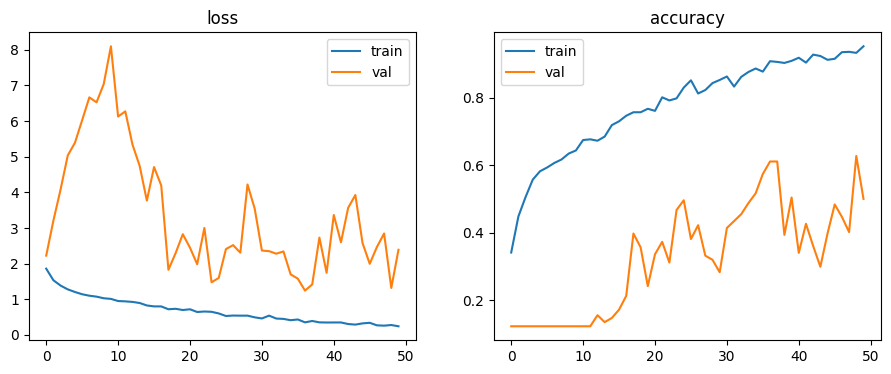

train window-level accuracy: 0.8193018436431885
val window-level accuracy: 0.5020576119422913
test window-level accuracy: 0.519832968711853
file-level test accuracy: 0.5454545454545454
              precision    recall  f1-score   support

       anger       0.54      1.00      0.71        55
     boredom       1.00      0.06      0.11        36
     disgust       0.00      0.00      0.00        26
        fear       0.53      0.73      0.62        33
   happiness       0.20      0.04      0.06        27
     neutral       0.46      0.70      0.56        27
     sadness       0.68      0.93      0.78        27

    accuracy                           0.55       231
   macro avg       0.49      0.49      0.40       231
weighted avg       0.52      0.55      0.44       231



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


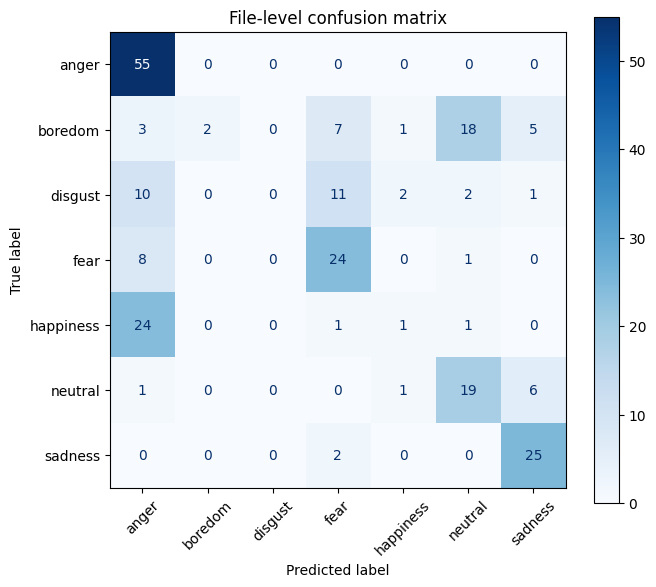

In [21]:
# loss/accuracy curves
hist = historic.history
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (k, title) in zip(ax, [('loss', 'loss'), ('accuracy', 'accuracy')]):
    a.plot(hist[k], label='train'); a.plot(hist['val_' + k], label='val')
    a.set_title(title); a.legend()
plt.show()

# window-level accuracy
n_val = int(0.2 * len(X_train))
X_tr, X_val = X_train[:-n_val], X_train[-n_val:]
y_tr, y_val = Y_train[:-n_val], Y_train[-n_val:]

for name, X, y in [('train', X_tr, y_tr), ('val', X_val, y_val), ('test', X_test, Y_test)]:
    print(name, 'window-level accuracy:', model.evaluate(X, y, verbose=0)[1])

# file-level accuracy
probs = model.predict(X_test, batch_size=64, verbose=0)
df_p = pd.DataFrame(probs)
df_p['file'] = test_df['file'].values

file_probs = df_p.groupby('file').mean()
file_true = pd.Series(Y_test, index=test_df['file'].values).groupby(level=0).first().loc[file_probs.index]
file_pred = file_probs.values.argmax(axis=1)

print('file-level test accuracy:', (file_pred == file_true.values).mean())
print(classification_report(file_true.values, file_pred, target_names=encoder.classes_))

cm = confusion_matrix(file_true.values, file_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
ax.set_title('File-level confusion matrix')
plt.tight_layout()
plt.show()